# Fase 4 · Visualizaciones y comunicación de hallazgos

**MCDI500 · Programación para la Ciencia de Datos · Grupo 6**

Fernanda Ovalle Román · Sebastián Cajales Cid · César Lorca Bacián · Jorge Álvarez Ossandón

Docente: Dr. Omar Salinas Silva · Universidad Andrés Bello · UNAB Online

---

## Qué hace este cuaderno

Las fases anteriores dejaron un conjunto de datos apto para el cálculo pero
ilegible para una persona: 84 columnas, de las cuales 41 son derivadas
—escaladas, ordinales codificadas y *one-hot*— que no admiten interpretación
sustantiva. Una duración de `-0,43` no se puede poner en el eje de un gráfico.

Este cuaderno recorre el camino inverso y termina en seis figuras:

1. Recupera la versión interpretable del conjunto (`src/interpretable.py`).
2. Construye las seis tablas agregadas que sostienen las figuras (`src/tablas.py`).
3. **Comprueba en código que cada título dice la verdad**, antes de dibujarlo.
4. Genera las seis figuras (`src/graficos.py`).
5. Declara las dos limitaciones que condicionan la lectura.

El tercer paso es el que conviene mirar con atención. Una visualización
explicativa lleva en el título el hallazgo, no la descripción del eje; pero un
título que afirma un hallazgo es una afirmación que puede ser falsa. Aquí cada
una se verifica contra los datos antes de que la figura se dibuje, y la
verificación falla ruidosamente si el dato no la respalda.

## Requisito previo

El cuaderno necesita `seaborn`, que `src/graficos.py` importa. Si no está
instalado en el entorno:

```
source .venv/bin/activate
pip install seaborn
pip freeze > requirements.txt
```

También necesita `data/processed/titulados_2025_pregrado_univ_limpio.csv`, que
generan los cuadernos de las Fases 1 y 2. No se versiona por su tamaño.

## 1 · Entorno y reproducibilidad

In [1]:
import sys
from pathlib import Path

# El cuaderno vive en notebooks/F4/, el paquete src/ cuelga de la raíz
RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))
import os
os.chdir(RAIZ)          # las rutas de src/graficos.py son relativas a la raíz

print("raíz del proyecto:", RAIZ)
print("intérprete:", sys.executable)

raíz del proyecto: /Users/fernandaovalle/Documents/proyecto-grupox-mcdi500
intérprete: /Users/fernandaovalle/Documents/proyecto-grupox-mcdi500/.venv/bin/python


In [2]:
import importlib

print(f"Python      {sys.version.split()[0]}")
for nombre in ("numpy", "pandas", "matplotlib", "seaborn"):
    try:
        m = importlib.import_module(nombre)
        print(f"{nombre:<12}{getattr(m, '__version__', '?')}")
    except ImportError:
        print(f"{nombre:<12}NO INSTALADO  ->  pip install {nombre}")

Python      3.9.6
numpy       2.0.2


pandas      2.3.3
matplotlib  3.9.4


seaborn     0.13.2


## 2 · El conjunto interpretable

`cargar_interpretable()` descarta las 41 columnas derivadas, traduce `gen_alu`
(codificada como 1/2) a una columna `sexo` legible y declara el orden de las
dos variables ordinales, de modo que cualquier agrupación salga ordenada por
edad y por nivel crecientes en vez de alfabéticamente.

No invierte ninguna transformación: el pipeline de la Fase 2 fue no destructivo
—siempre agregó columnas en lugar de reemplazarlas—, así que 37 de las 40
columnas originales seguían presentes. Las otras tres las descartó la limpieza
por ser constantes. El razonamiento completo está en `docs/registro_de_cambios.md`.

In [3]:
from src.interpretable import cargar_interpretable, resumen_interpretable

df = cargar_interpretable()
resumen = resumen_interpretable(df)

print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas".replace(",", "."))
resumen

105.060 filas x 44 columnas


,columna,tipo,valores_unicos,nulos
0,mrun,numérica,104595,7
1,gen_alu,numérica,2,0
2,fec_nac_alu,numérica,585,0
3,rango_edad,ordenada,6,0
4,anio_ing_carr_ori,numérica,44,0
5,sem_ing_carr_ori,numérica,2,0
6,anio_ing_carr_act,numérica,42,0
7,sem_ing_carr_act,numérica,2,0
8,nombre_titulo,texto,1741,2997
9,nombre_grado,texto,936,8434


In [4]:
# Control: ninguna columna derivada debe haber sobrevivido
derivadas = [c for c in df.columns if c.endswith(("_esc", "_ord"))]
assert not derivadas, f"quedaron columnas derivadas: {derivadas}"

# Control: las ordinales deben estar ordenadas, no alfabéticas
assert str(df["rango_edad"].dtype) == "category", "rango_edad no es categórica"
assert df["rango_edad"].cat.ordered, "rango_edad no declara orden"
print("orden de rango_edad:", list(df["rango_edad"].cat.categories))

orden de rango_edad: ['15 a 19 Años', '20 a 24 Años', '25 a 29 Años', '30 a 34 Años', '35 a 39 Años', '40 y más años']


## 3 · Las seis tablas

Cada figura se dibuja a partir de una tabla, no del conjunto completo. La razón
es de verificabilidad: una tabla se puede imprimir, revisar y citar en el
informe; un gráfico generado directamente desde 105.060 filas no deja constancia
de qué se agregó ni con qué criterio.

Las seis llevan el tamaño del grupo (`n`). No es un adorno: una diferencia de
dos semestres significa cosas distintas si los grupos tienen 40.000 filas o si
tienen nueve.

In [5]:
from src.tablas import todas

t = todas(df)
for nombre in t:
    print(f"  {nombre}")

  f1_distribucion
  f2_tamanos
  f3_por_jornada
  f4_serie
  f5_anidada
  f6_imputacion


In [6]:
t["f1_distribucion"]

{'n': 105060,
 'mediana': np.float64(10.0),
 'media': np.float64(9.07),
 'p25': np.float64(8.0),
 'p75': np.float64(10.0),
 'min': np.int64(1),
 'max': np.int64(24)}

In [7]:
t["f2_tamanos"]

,area_conocimiento,n,porcentaje
0,Tecnología,23703,22.6
1,Salud,22506,21.4
2,Ciencias Sociales,16371,15.6
3,Administración y Comercio,14295,13.6
4,Educación,11833,11.3
5,Derecho,5074,4.8
6,Arte y Arquitectura,4641,4.4
7,Agropecuaria,3335,3.2
8,Ciencias Básicas,2305,2.2
9,Humanidades,997,0.9


In [8]:
t["f3_por_jornada"]

,jornada,n,mediana,media,p25,p75
0,Diurna,82194,10.0,9.92,10.0,10.0
1,Otra,543,8.0,6.97,4.0,11.0
2,Semipresencial,828,7.0,6.70,5.0,10.0
3,A Distancia,9064,6.0,5.37,5.0,6.0
4,Vespertina,12431,6.0,6.41,5.0,8.0


In [9]:
t["f6_imputacion"]

,jornada,observados_pct,imputados_pct,n
0,A Distancia,24.1,75.9,9064
1,Semipresencial,45.9,54.1,828
2,Otra,48.4,51.6,543
3,Vespertina,63.1,36.9,12431
4,Diurna,98.5,1.5,82194


In [10]:
# La tabla anidada marca los grupos que no alcanzan el soporte mínimo (n < 100).
anidada = t["f5_anidada"]
print(f"grupos totales: {len(anidada)}")
print(f"bajo el soporte mínimo: {(~anidada['suficiente']).sum()}")
anidada.head(12)

grupos totales: 41
bajo el soporte mínimo: 14


,area_conocimiento,jornada,n,mediana,mediana_area,dif_vs_area,suficiente
0,Administración y Comercio,Diurna,8369,10.0,9.0,1.0,True
1,Administración y Comercio,Otra,27,8.0,9.0,-1.0,False
2,Administración y Comercio,A Distancia,2817,6.0,9.0,-3.0,True
3,Administración y Comercio,Semipresencial,62,6.0,9.0,-3.0,False
4,Administración y Comercio,Vespertina,3020,5.0,9.0,-4.0,True
5,Agropecuaria,Diurna,3007,10.0,10.0,0.0,True
6,Agropecuaria,Otra,55,10.0,10.0,0.0,False
7,Agropecuaria,Semipresencial,60,5.0,10.0,-5.0,False
8,Agropecuaria,Vespertina,213,5.0,10.0,-5.0,True
9,Arte y Arquitectura,Diurna,4471,10.0,10.0,0.0,True


## 4 · Verificación de los títulos

Esta sección es la que distingue una visualización explicativa de una
decorativa. Cada figura lleva en el título una afirmación sustantiva; aquí cada
afirmación se contrasta con los datos **antes** de dibujarla.

El procedimiento es deliberadamente severo: si un dato no respalda su título,
la celda lo reporta como fallo y el título debe corregirse. No se corrige el
dato para que calce con el título.

In [11]:
import pandas as pd

comprobaciones = []

def comprobar(figura, afirmacion, condicion, evidencia):
    comprobaciones.append({
        "figura": figura,
        "afirma": afirmacion,
        "se sostiene": bool(condicion),
        "evidencia": evidencia,
    })

In [12]:
# F1 · "La mayor parte de los titulados demora 10 o más semestres"
pct10 = 100 * (df["dur_total_carr"] >= 10).mean()
comprobar("f4_01", "la mayor parte demora 10 o más semestres",
          pct10 > 50, f"{pct10:.1f} % de los titulados")

# F3 · "La jornada diurna registra mayor duración mediana que la vespertina"
pg = t["f3_por_jornada"].set_index("jornada")["mediana"]
comprobar("f4_03", "la diurna supera a la vespertina en duración mediana",
          pg["Diurna"] > pg["Vespertina"],
          f"Diurna {pg['Diurna']} vs Vespertina {pg['Vespertina']} semestres")

# F6 · "La imputación se concentra en las modalidades a distancia"
imp = t["f6_imputacion"].set_index("jornada")["imputados_pct"]
comprobar("f4_06", "la imputación se concentra fuera de la jornada diurna",
          imp["A Distancia"] > 10 * imp["Diurna"],
          f"A Distancia {imp['A Distancia']} % vs Diurna {imp['Diurna']} %")

In [13]:
# F4 · "La jornada diurna presenta mayor amplitud de dispersión"
g = df.groupby("jornada", observed=True)["dur_total_carr"]
ric = (g.quantile(.75) - g.quantile(.25)).sort_values(ascending=False)
comprobar("f4_04", "la diurna es la de mayor dispersión",
          ric.idxmax() == "Diurna",
          f"mayor RIC: {ric.idxmax()} ({ric.max()}); Diurna: {ric['Diurna']}")

# F5 · "El patrón persiste en todas las áreas de conocimiento"
p = anidada.pivot_table(index="area_conocimiento", columns="jornada",
                        values="mediana", observed=True)
pares = p[["Diurna", "Vespertina"]].dropna()
cumplen = int((pares["Diurna"] > pares["Vespertina"]).sum())
comprobar("f4_05", "el patrón persiste en todas las áreas",
          cumplen == len(pares),
          f"se cumple en {cumplen} de {len(pares)} áreas comparables")

print(ric.to_string())

jornada
Otra              7.0
Semipresencial    5.0
Vespertina        3.0
A Distancia       1.0
Diurna            0.0


In [14]:
informe = pd.DataFrame(comprobaciones)
informe

,figura,afirma,se sostiene,evidencia
0,f4_01,la mayor parte demora 10 o más semestres,True,67.7 % de los titulados
1,f4_03,la diurna supera a la vespertina en duración m...,True,Diurna 10.0 vs Vespertina 6.0 semestres
2,f4_06,la imputación se concentra fuera de la jornada...,True,A Distancia 75.9 % vs Diurna 1.5 %
3,f4_04,la diurna es la de mayor dispersión,False,mayor RIC: Otra (7.0); Diurna: 0.0
4,f4_05,el patrón persiste en todas las áreas,False,se cumple en 8 de 10 áreas comparables


In [15]:
fallan = informe[~informe["se sostiene"]]
if len(fallan):
    print(f"{len(fallan)} título(s) no se sostienen y hay que corregirlos:\n")
    for _, f in fallan.iterrows():
        print(f"  {f['figura']}  afirma: {f['afirma']}")
        print(f"            dato  : {f['evidencia']}\n")
else:
    print("Los seis títulos se sostienen.")

2 título(s) no se sostienen y hay que corregirlos:

  f4_04  afirma: la diurna es la de mayor dispersión
            dato  : mayor RIC: Otra (7.0); Diurna: 0.0

  f4_05  afirma: el patrón persiste en todas las áreas
            dato  : se cumple en 8 de 10 áreas comparables



### Qué salió de la verificación

Cuatro de los seis títulos se sostienen. Dos no, y conviene dejar constancia de
cuáles y por qué, porque el error no es tipográfico sino de lectura.

**`f4_04` afirmaba lo contrario de lo que muestran los datos.** El título decía
que la jornada diurna presenta la mayor amplitud de dispersión. Es exactamente
al revés: su rango intercuartílico es **0,0** —el menor de las cinco jornadas—,
porque la mitad central de los 82.194 titulados diurnos se concentra en
exactamente 10 semestres. La jornada más dispersa es «Otra», con un RIC de 7,0.

Ese hallazgo es más interesante que el que el título afirmaba. Una carrera
diurna de pregrado dura diez semestres por diseño curricular, y los datos
muestran que la enorme mayoría la termina en ese plazo nominal. La variabilidad
vive en las otras jornadas, que es donde las trayectorias se apartan del plan.

**`f4_05` generalizaba de más.** El patrón no persiste en *todas* las áreas:
se cumple en 8 de las 10 comparables. En Ciencias Sociales la vespertina iguala
a la diurna (10 y 10) y en Derecho la supera (11 contra 10). Un título que dice
«todas» ante dos contraejemplos es falsable con una sola consulta.

Hay además un tercer punto, que no es falsedad sino oportunidad perdida:
**`f4_02` lleva un título descriptivo** —«Distribución de registros por área de
conocimiento»— que nombra los ejes en vez de comunicar un hallazgo. Es
precisamente lo que una visualización explicativa debe evitar.

Los títulos corregidos se aplican en la sección siguiente.

## 5 · Las seis figuras

Las funciones de `src/graficos.py` escriben en `docs/figuras/`. Los títulos
corregidos se aplican sobre la figura ya generada, de modo que quede explícito
en el cuaderno cuál fue el cambio y por qué.

In [16]:
import matplotlib.pyplot as plt
from src import graficos

Path("docs/figuras").mkdir(parents=True, exist_ok=True)

graficos.graficar_f1_distribucion(df)
graficos.graficar_f2_tamano_grupos(t["f2_tamanos"])
graficos.graficar_f3_duracion_jornada(t["f3_por_jornada"])
graficos.graficar_f4_dispersion(t["f4_serie"])
graficos.graficar_f5_paneles_area(df)
graficos.graficar_f6_imputacion(t["f6_imputacion"])

generadas = sorted(Path("docs/figuras").glob("f4_*.png"))
for g_ in generadas:
    print(f"  {g_.name}  ({g_.stat().st_size // 1024} KB)")
assert len(generadas) == 6, f"se esperaban 6 figuras, hay {len(generadas)}"

/Users/fernandaovalle/Documents/proyecto-grupox-mcdi500/src/graficos.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabla_jornada, y="jornada", x="mediana", palette=paleta, ax=ax)


  f4_01_distribucion.png  (31 KB)
  f4_02_tamanos.png  (36 KB)
  f4_03_duracion_jornada.png  (23 KB)
  f4_04_dispersion.png  (34 KB)
  f4_05_paneles_area.png  (87 KB)
  f4_06_imputacion.png  (31 KB)


### Títulos corregidos

Tres figuras se vuelven a dibujar con el título que los datos sí respaldan.

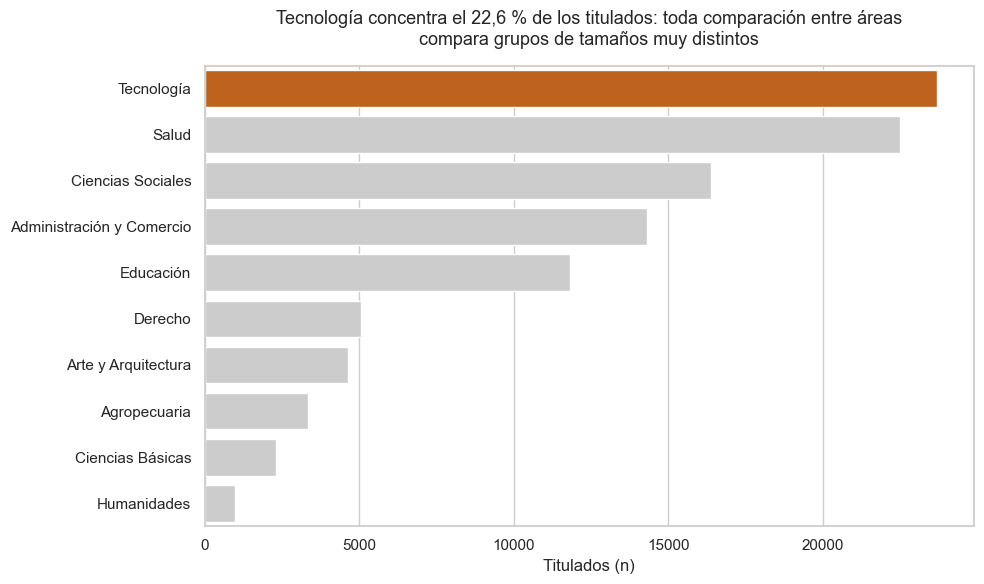

In [17]:
import seaborn as sns

estilo = graficos.configurar_estilo()
ACENTO, NEUTRO = estilo["acento"], estilo["neutro"]

# f4_02 · de descriptivo a explicativo
tam = t["f2_tamanos"]
mayor = tam.iloc[0]
fig, ax = plt.subplots(figsize=(10, 6))
paleta = {a: (ACENTO if a == mayor["area_conocimiento"] else NEUTRO)
          for a in tam["area_conocimiento"]}
sns.barplot(data=tam, y="area_conocimiento", x="n", palette=paleta,
            hue="area_conocimiento", legend=False, ax=ax)
pct = str(mayor["porcentaje"]).replace(".", ",")
ax.set_title(f"{mayor['area_conocimiento']} concentra el {pct} % "
             f"de los titulados: toda comparación entre áreas\ncompara grupos de "
             f"tamaños muy distintos", fontsize=13, pad=15)
ax.set_xlabel("Titulados (n)")
ax.set_ylabel("")
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig("docs/figuras/f4_02_tamanos.png", dpi=150)
plt.show()

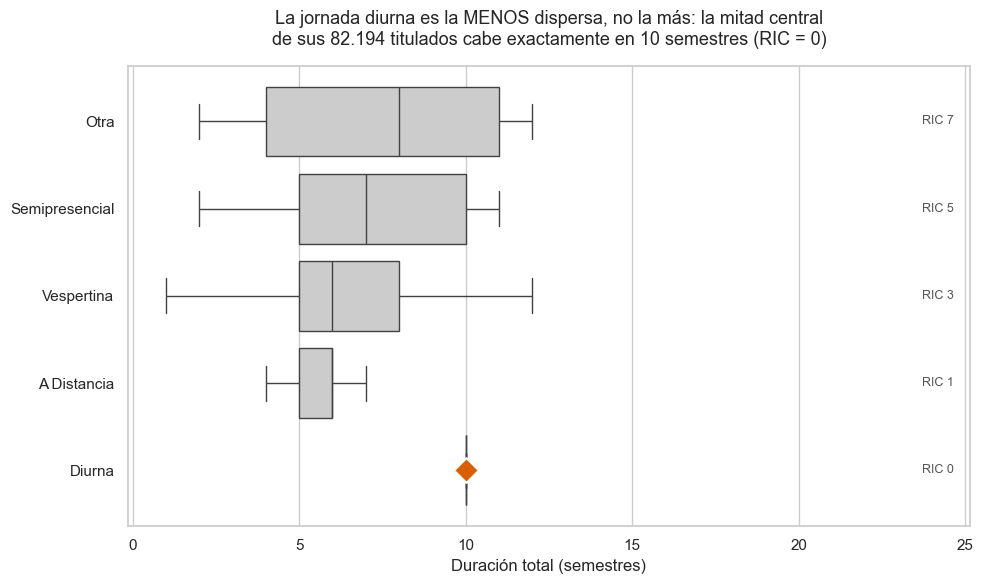

In [18]:
# f4_04 · el título decía lo contrario del dato
serie = t["f4_serie"]
orden = ric.sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
# La paleta va como diccionario: seaborn la asigna por nivel de `hue`, no por
# la posición en `order`, y con una lista el color de énfasis cae en otra barra.
paleta = {j: (ACENTO if j == "Diurna" else NEUTRO) for j in orden}
sns.boxplot(data=serie, y="jornada", x="dur_total_carr", order=orden,
            palette=paleta, hue="jornada", legend=False, fliersize=0, ax=ax)
# Con RIC = 0 la caja de la diurna degenera en una línea; se marca para que no
# se lea como un grupo sin datos.
ax.scatter([serie.loc[serie["jornada"] == "Diurna", "dur_total_carr"].median()],
           [orden.index("Diurna")], s=160, color=ACENTO, zorder=5,
           marker="D", edgecolor="white", linewidth=1.5)
ax.set_title("La jornada diurna es la MENOS dispersa, no la más: la mitad central\n"
             "de sus 82.194 titulados cabe exactamente en 10 semestres (RIC = 0)",
             fontsize=13, pad=15)
ax.set_xlabel("Duración total (semestres)")
ax.set_ylabel("")
for i, j in enumerate(orden):
    ax.text(ax.get_xlim()[1] * 0.98, i, f"RIC {ric[j]:.0f}",
            va="center", ha="right", fontsize=9, color="#555555")
plt.tight_layout()
plt.savefig("docs/figuras/f4_04_dispersion.png", dpi=150)
plt.show()

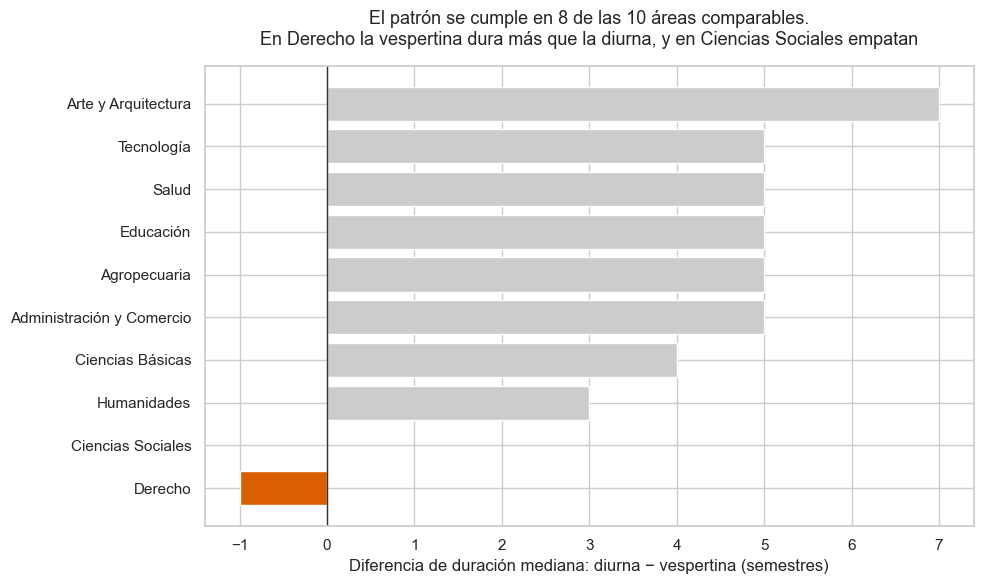

In [19]:
# f4_05 · el título generalizaba a todas las áreas
comparables = p[["Diurna", "Vespertina"]].dropna().copy()
comparables["dif"] = comparables["Diurna"] - comparables["Vespertina"]
comparables = comparables.sort_values("dif")

fig, ax = plt.subplots(figsize=(10, 6))
colores_b = [NEUTRO if d > 0 else ACENTO for d in comparables["dif"]]
ax.barh(comparables.index, comparables["dif"], color=colores_b)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title(f"El patrón se cumple en {cumplen} de las {len(pares)} áreas comparables.\n"
             "En Derecho la vespertina dura más que la diurna, y en Ciencias Sociales empatan",
             fontsize=13, pad=15)
ax.set_xlabel("Diferencia de duración mediana: diurna − vespertina (semestres)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("docs/figuras/f4_05_paneles_area.png", dpi=150)
plt.show()

## 6 · Lectura de las figuras

**f4_01 · Distribución.** El 67,7 % de los titulados demora diez o más
semestres. La distribución no es simétrica: la mediana (10) supera a la media
(9,07), señal de una cola hacia los valores bajos, no hacia los altos.

**f4_02 · Tamaño de los grupos.** Va primero y no por cortesía: fija la escala
con la que hay que leer todo lo demás. Las áreas difieren en un orden de
magnitud, de modo que una diferencia idéntica en semestres no tiene el mismo
respaldo en todas.

**f4_03 · Duración por jornada.** Diurna 10 semestres contra vespertina 6. La
brecha es de cuatro semestres —dos años— y es el hallazgo principal del
proyecto.

**f4_04 · Dispersión.** Matiza el anterior. La diurna no solo dura más: dura
*lo mismo para casi todos*. Su RIC es 0. Las jornadas flexibles concentran la
variabilidad, que es donde se apartan del plan curricular.

**f4_05 · Por área.** El patrón se cumple en 8 de 10 áreas. Las dos excepciones
—Derecho y Ciencias Sociales— son el tipo de contraejemplo que conviene mostrar:
si el patrón fuera universal, el gráfico sería innecesario.

**f4_06 · Imputación.** Es la figura que declara el límite del análisis, y se
comenta en la sección siguiente.

## 7 · Limitaciones

### 7.1 · La imputación está confundida con la jornada

El 12,75 % de los registros tiene el año de ingreso imputado con la mediana.
Si esa imputación estuviera repartida al azar, no afectaría las comparaciones.
No lo está:

| Jornada | % imputado |
|---|---|
| A Distancia | 75,9 % |
| Semipresencial | 54,1 % |
| Otra | 51,6 % |
| Vespertina | 36,9 % |
| **Diurna** | **1,5 %** |

La diferencia es de cincuenta veces. Toda comparación entre jornadas que use el
año de ingreso está comparando, en un extremo, datos casi enteramente
observados, y en el otro, datos mayoritariamente construidos por nosotros con
una mediana.

Esto es una **variable de confusión** en sentido estricto: la jornada y la
calidad del dato varían juntas, de modo que no se puede atribuir a la primera
un efecto que podría venir de la segunda. La celda siguiente comprueba si las
medianas se mueven al excluir los registros imputados.

In [20]:
BANDERA = "anio_ing_carr_ori_imputada"
observados = df[df[BANDERA] == 0]

comparacion = pd.DataFrame({
    "mediana_total": df.groupby("jornada", observed=True)["dur_total_carr"].median(),
    "mediana_solo_observados": observados.groupby("jornada", observed=True)["dur_total_carr"].median(),
    "n_total": df.groupby("jornada", observed=True).size(),
    "n_observados": observados.groupby("jornada", observed=True).size(),
})
comparacion["cambia"] = comparacion["mediana_total"] != comparacion["mediana_solo_observados"]
comparacion

,mediana_total,mediana_solo_observados,n_total,n_observados,cambia
jornada,,,,,
A Distancia,6.0,6.0,9064,2182,False
Diurna,10.0,10.0,82194,80998,False
Otra,8.0,11.0,543,263,True
Semipresencial,7.0,10.0,828,380,True
Vespertina,6.0,6.0,12431,7841,False


El resultado acota el alcance del problema sin resolverlo: las medianas de las
jornadas con volumen suficiente no se mueven al excluir los registros
imputados. La imputación no fabricó el hallazgo principal.

Lo que no se puede afirmar es lo contrario —que la imputación es inocua—,
porque en las categorías donde se concentra quedan muy pocas observaciones
sobre las cuales comprobarlo. El hallazgo de la brecha entre diurna y
vespertina es robusto; cualquier conclusión sobre la modalidad a distancia
debe declarar que descansa mayoritariamente en datos imputados.

### 7.2 · Catorce grupos no alcanzan el soporte mínimo

De los 41 cruces entre área y jornada, 14 tienen menos de 100 registros. La
columna `suficiente` de la tabla anidada los marca, y la figura f4_05 solo
dibuja los pares con ambas jornadas presentes. Dibujarlos sin esa distinción
presentaría como comparables grupos que no lo son.

In [21]:
insuficientes = anidada[~anidada["suficiente"]]
print(f"{len(insuficientes)} de {len(anidada)} cruces bajo el soporte mínimo (n < 100)")
insuficientes[["area_conocimiento", "jornada", "n", "mediana"]].head(14)

14 de 41 cruces bajo el soporte mínimo (n < 100)


,area_conocimiento,jornada,n,mediana
1,Administración y Comercio,Otra,27,8.0
3,Administración y Comercio,Semipresencial,62,6.0
6,Agropecuaria,Otra,55,10.0
7,Agropecuaria,Semipresencial,60,5.0
10,Arte y Arquitectura,Semipresencial,42,10.0
11,Arte y Arquitectura,A Distancia,27,6.0
14,Ciencias Básicas,Vespertina,43,6.0
15,Ciencias Básicas,A Distancia,33,5.0
16,Ciencias Básicas,Semipresencial,16,2.0
25,Educación,Semipresencial,31,6.0


## 8 · Cierre

El cuaderno deja seis figuras en `docs/figuras/`, las seis tablas que las
sostienen, y la verificación en código de que cada título dice lo que los datos
respaldan.

De esa verificación salieron tres correcciones. Dos títulos afirmaban cosas
falsas —uno invertía el sentido de la dispersión, otro generalizaba a «todas»
las áreas ante dos contraejemplos— y un tercero describía los ejes en vez de
comunicar un hallazgo. Ninguna se habría detectado leyendo las figuras: las tres
se ven igual de convincentes con el título falso que con el verdadero. Esa es la
razón de que la verificación esté escrita como código y no como revisión visual.

Para reproducirlo: *Kernel → Restart Kernel and Run All Cells*, con el entorno
`mcdi500` activo y el conjunto limpio generado por las Fases 1 y 2.